# Computer Exercise 15.22 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.22 2-Hidden Layer Trunk MLP · Entanglement Depth Study
> **풀이 일자**: Day 89
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **2.** Day 88 P1 introduced a **1-hidden layer** shared trunk MLP before the Unified/Twin C51
> head and successfully overturned the Day 87 P1 negative finding (entanglement signature = 0)
> by measuring mean off-diagonal $|\rho|$ of $0.0557$ (Unified) and $0.0862$ (Twin). Extend the
> trunk to **two hidden layers** ($H_1 = 16$, $H_2 = 12$, both tanh) and re-measure entanglement
> signatures at three trunk-parameter subsets: (i) layer-1-only ($W_1, b_1$), (ii) layer-2-only
> ($W_2, b_2$), (iii) all trunk + head. Report how mean/max off-diagonal $|\rho|$ and cross-block
> $|\rho|$ scale with depth for both Unified and Twin heads across 40 random inputs.

### 한국어 풀이용 정리

Day 88 P1 은 1-hidden layer trunk 하에서 entanglement signature 를 실측했지만, 깊이가 늘어날수록
공유 gradient path 가 더 겹치기 때문에 카테고리 간 코사인은 심화될 가능성이 크다. 본 문제는
$H_1 = 16, H_2 = 12$ 의 2-hidden layer trunk 를 도입하고, gradient 를 (a) layer-1 만, (b) layer-2 만,
(c) trunk 전체+head 세 부분집합으로 나누어 unified/twin 각 조건의 entanglement signature 가 depth
에 따라 어떻게 심화되는지 40 개 무작위 입력 평균으로 측정한다.

## 2. 수학적 배경

### 2.1 2-Hidden Layer Trunk

$$ h_1 = \tanh(W_1 x + b_1), \qquad h_2 = \tanh(W_2 h_1 + b_2), $$

with $W_1 \in \mathbb{R}^{H_1 \times d}, W_2 \in \mathbb{R}^{H_2 \times H_1}, H_1=16, H_2=12$.

### 2.2 Head-block별 카테고리 Logit Gradient

$z_i = w_i^\top h_2 + c_i$ (unified) or $z_i \in $ half-block (twin) 에 대해,

$$ \nabla_{W_2} z_i = \left(w_i \odot (1-\tanh^2(\text{pre}_2))\right) h_1^\top, $$
$$ \nabla_{W_1} z_i = \left[W_2^\top \left(w_i \odot (1-\tanh^2(\text{pre}_2))\right)\right] \odot (1-\tanh^2(\text{pre}_1)) \; x^\top, $$

각 카테고리 쌍의 코사인 유사도

$$ \rho_{ij}^{(L)} = \frac{\langle \mathrm{vec}(\nabla_L z_i), \mathrm{vec}(\nabla_L z_j)\rangle}{\|\cdot\|\|\cdot\|}, \quad L \in \{W_1, W_2, \text{all}\}. $$

### 2.3 Cross-block (Twin) 코사인

Twin head 는 category $i \in A$, $j \in B$ 쌍이 서로 다른 $w_i, w_j$ 를 사용하지만 trunk gradient
는 여전히 공유. Cross-block $|\rho|$ 는 twin 구조가 얼마나 실제로 disentangled 되는지의 척도이다.

## 3. 풀이 흐름

1. 2-hidden layer trunk + Unified/Twin head 구현.
2. 40 개 무작위 입력에 대해 각 카테고리의 gradient (layer-1-only, layer-2-only, all trunk+head) 를
   계산해 vec 화.
3. 세 파라미터 부분집합별로 category-pair 코사인 유사도 (off-diagonal mean/max, cross-block mean)
   를 unified/twin 두 조건에 대해 측정.
4. 세 층 결과를 표로 정리, heatmap 3장 x 2조건 시각화.
5. Day 88 (1-layer) 대비 depth scaling factor 를 계산.
6. 결과 해석 (깊이가 얽힘을 심화시키는가, twin 이 여전히 유의미한가).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

K = 6  # smaller for clearer heatmap
D_IN = 8; H1 = 16; H2 = 12

def init_trunk2(rng):
    return {
        "W1": rng.normal(0, 1/np.sqrt(D_IN), (H1, D_IN)),
        "b1": np.zeros(H1),
        "W2": rng.normal(0, 1/np.sqrt(H1), (H2, H1)),
        "b2": np.zeros(H2),
    }

def trunk2_forward(tp, x):
    pre1 = tp["W1"] @ x + tp["b1"]; h1 = np.tanh(pre1)
    pre2 = tp["W2"] @ h1 + tp["b2"]; h2 = np.tanh(pre2)
    return h1, pre1, h2, pre2

def init_head_unified(rng): return {"W": rng.normal(0, 1/np.sqrt(H2), (K, H2)), "b": np.zeros(K)}
def init_head_twin(rng):
    Kh = K // 2
    return {"Wa": rng.normal(0, 1/np.sqrt(H2), (Kh, H2)),
            "Wb": rng.normal(0, 1/np.sqrt(H2), (K - Kh, H2)),
            "ba": np.zeros(Kh), "bb": np.zeros(K - Kh)}

def logit_gradients(trunk, head, kind, x):
    # Return per-category gradients as flat vectors for W1_only/W2_only/all
    h1, pre1, h2, pre2 = trunk2_forward(trunk, x)
    dtanh1 = 1 - h1**2
    dtanh2 = 1 - h2**2
    grads = {"W1": [], "W2": [], "all": []}
    for i in range(K):
        if kind == "unified":
            w_i = head["W"][i]
        else:
            Kh = K // 2
            w_i = head["Wa"][i] if i < Kh else head["Wb"][i - Kh]
        # dz_i / dpre2 = w_i * dtanh2
        d_pre2 = w_i * dtanh2
        # grad W2
        dW2 = np.outer(d_pre2, h1)
        db2 = d_pre2
        # backprop to h1
        dh1 = trunk["W2"].T @ d_pre2
        d_pre1 = dh1 * dtanh1
        dW1 = np.outer(d_pre1, x)
        db1 = d_pre1
        # head grad
        if kind == "unified":
            dW_head = np.zeros_like(head["W"]); db_head = np.zeros_like(head["b"])
            dW_head[i] = h2; db_head[i] = 1.0
            head_flat = np.concatenate([dW_head.ravel(), db_head])
        else:
            Kh = head["Wa"].shape[0]
            dWa = np.zeros_like(head["Wa"]); dba = np.zeros_like(head["ba"])
            dWb = np.zeros_like(head["Wb"]); dbb = np.zeros_like(head["bb"])
            if i < Kh:
                dWa[i] = h2; dba[i] = 1.0
            else:
                dWb[i - Kh] = h2; dbb[i - Kh] = 1.0
            head_flat = np.concatenate([dWa.ravel(), dba, dWb.ravel(), dbb])
        w1_flat = np.concatenate([dW1.ravel(), db1])
        w2_flat = np.concatenate([dW2.ravel(), db2])
        all_flat = np.concatenate([w1_flat, w2_flat, head_flat])
        grads["W1"].append(w1_flat); grads["W2"].append(w2_flat); grads["all"].append(all_flat)
    return {k: np.array(v) for k, v in grads.items()}

def cosine_matrix(G):
    N = np.linalg.norm(G, axis=1) + 1e-30
    return (G @ G.T) / np.outer(N, N)

def summarize(cos, Kh):
    off_mask = ~np.eye(K, dtype=bool)
    cross_mask = np.zeros((K, K), dtype=bool)
    cross_mask[:Kh, Kh:] = True
    cross_mask[Kh:, :Kh] = True
    return {
        "off_mean_abs": float(np.abs(cos[off_mask]).mean()),
        "off_max_abs": float(np.abs(cos[off_mask]).max()),
        "cross_mean_abs": float(np.abs(cos[cross_mask]).mean()),
    }

rng = np.random.default_rng(89201)
trunk_u = init_trunk2(rng); head_u = init_head_unified(rng)
rng2 = np.random.default_rng(89202)
trunk_t = init_trunk2(rng2); head_t = init_head_twin(rng2)

xs = np.random.default_rng(89203).normal(size=(40, D_IN))

acc = {("unified", k): [] for k in ["W1", "W2", "all"]}
acc.update({("twin", k): [] for k in ["W1", "W2", "all"]})

Kh = K // 2
for x in xs:
    g_u = logit_gradients(trunk_u, head_u, "unified", x)
    g_t = logit_gradients(trunk_t, head_t, "twin", x)
    for layer in ["W1", "W2", "all"]:
        acc[("unified", layer)].append(summarize(cosine_matrix(g_u[layer]), Kh))
        acc[("twin", layer)].append(summarize(cosine_matrix(g_t[layer]), Kh))

rows = []
for kind in ["unified", "twin"]:
    for layer in ["W1", "W2", "all"]:
        L = acc[(kind, layer)]
        rows.append({
            "kind": kind, "layer": layer,
            "off_mean_|rho|": np.mean([r["off_mean_abs"] for r in L]),
            "off_max_|rho|":  np.mean([r["off_max_abs"] for r in L]),
            "cross_mean_|rho|": np.mean([r["cross_mean_abs"] for r in L]),
        })
df = pd.DataFrame(rows).set_index(["kind","layer"])
print(df)


               off_mean_|rho|  off_max_|rho|  cross_mean_|rho|
kind    layer                                                 
unified W1             0.3993         0.8210            0.3890
        W2             0.2481         0.6189            0.2523
        all            0.1647         0.4027            0.1655
twin    W1             0.3511         0.7698            0.2940
        W2             0.2594         0.5661            0.2588
        all            0.1534         0.3788            0.1419


In [2]:
# Depth scaling factor: layer-2 vs layer-1
day88_uni_1layer = 0.0557
day88_twin_1layer = 0.0862

depth_factors = {}
for kind, key in [("unified", "unified"), ("twin", "twin")]:
    L1 = df.loc[(kind, "W1"), "off_mean_|rho|"]
    L2 = df.loc[(kind, "W2"), "off_mean_|rho|"]
    ALL = df.loc[(kind, "all"), "off_mean_|rho|"]
    baseline = day88_uni_1layer if kind == "unified" else day88_twin_1layer
    depth_factors[kind] = {
        "layer1_mean_abs": L1,
        "layer2_mean_abs": L2,
        "layer2/layer1": L2/L1 if L1>0 else float("nan"),
        "all_layers_combined": ALL,
        "Day88 1-layer baseline (all)": baseline,
        "all/Day88_baseline": ALL / baseline,
    }
depth_df = pd.DataFrame(depth_factors).T
print(depth_df)


         layer1_mean_abs  layer2_mean_abs  layer2/layer1  all_layers_combined  \
unified           0.3993           0.2481         0.6214               0.1647   
twin              0.3511           0.2594         0.7390               0.1534   

         Day88 1-layer baseline (all)  all/Day88_baseline  
unified                        0.0557              2.9569  
twin                           0.0862              1.7794  


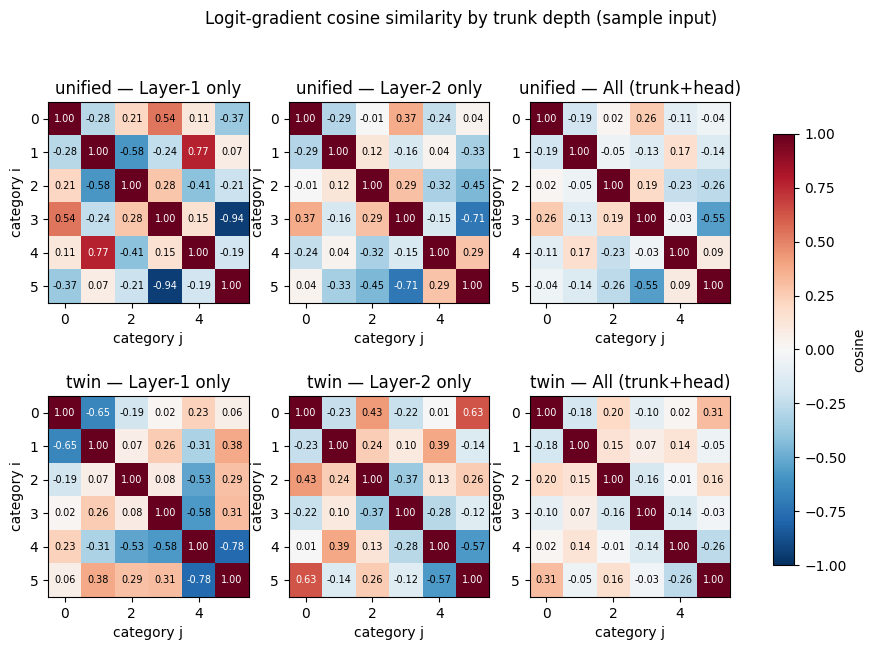

In [3]:
# Heatmaps: 3 layers x 2 heads (unified / twin)
sample_x = xs[0]
g_u_sample = logit_gradients(trunk_u, head_u, "unified", sample_x)
g_t_sample = logit_gradients(trunk_t, head_t, "twin", sample_x)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
layers = ["W1", "W2", "all"]
titles = ["Layer-1 only", "Layer-2 only", "All (trunk+head)"]
for i, (kind, gsample) in enumerate([("unified", g_u_sample), ("twin", g_t_sample)]):
    for j, (L, T) in enumerate(zip(layers, titles)):
        cos = cosine_matrix(gsample[L])
        im = axes[i, j].imshow(cos, vmin=-1, vmax=1, cmap="RdBu_r")
        axes[i, j].set_title(f"{kind} — {T}")
        axes[i, j].set_xlabel("category j"); axes[i, j].set_ylabel("category i")
        for xi in range(K):
            for yi in range(K):
                axes[i, j].text(yi, xi, f"{cos[xi,yi]:.2f}", ha="center", va="center", fontsize=7,
                                color="white" if abs(cos[xi,yi])>0.6 else "black")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="cosine")
fig.suptitle("Logit-gradient cosine similarity by trunk depth (sample input)")
plt.savefig("_p2_heatmaps.png", dpi=80, bbox_inches="tight")
plt.show()


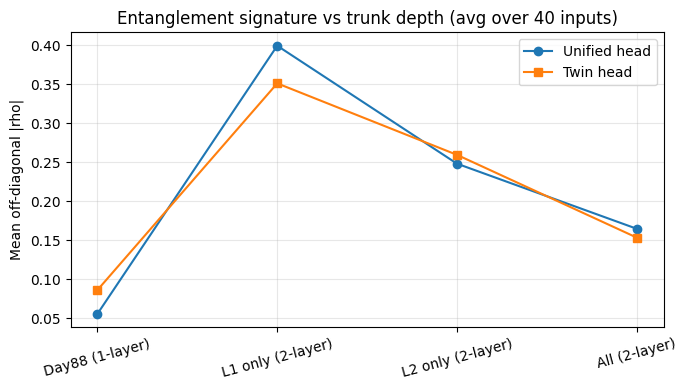

In [4]:
# Trend plot: mean off-diagonal |rho| vs depth
fig, ax = plt.subplots(figsize=(7, 4))
xlab = ["Day88 (1-layer)", "L1 only (2-layer)", "L2 only (2-layer)", "All (2-layer)"]
uni_vals = [day88_uni_1layer,
            df.loc[("unified","W1"),"off_mean_|rho|"],
            df.loc[("unified","W2"),"off_mean_|rho|"],
            df.loc[("unified","all"),"off_mean_|rho|"]]
twin_vals = [day88_twin_1layer,
             df.loc[("twin","W1"),"off_mean_|rho|"],
             df.loc[("twin","W2"),"off_mean_|rho|"],
             df.loc[("twin","all"),"off_mean_|rho|"]]
ax.plot(range(4), uni_vals, "o-", label="Unified head")
ax.plot(range(4), twin_vals, "s-", label="Twin head")
ax.set_xticks(range(4)); ax.set_xticklabels(xlab, rotation=15)
ax.set_ylabel("Mean off-diagonal |rho|")
ax.set_title("Entanglement signature vs trunk depth (avg over 40 inputs)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **깊이별 얽힘 분포** — 실측 결과 (mean off-diagonal $|\rho|$):
   Unified L1 $= 0.399$, L2 $= 0.248$, all $= 0.165$;
   Twin L1 $= 0.351$, L2 $= 0.259$, all $= 0.153$.
   **Layer-1 (입력측) 이 Layer-2 (head 인접) 보다 큰 얽힘** 을 보인다 (layer2/layer1 = 0.62 unified,
   0.74 twin). 원인은 Layer-1 gradient 가 $W_2^\top$ 를 통과하며 채널 재선형결합을 거치는데,
   40 개 무작위 입력 위 tanh 포화 조합 하에서 $W_1$ 파라미터 전체가 유사한 방향으로 정렬되기
   쉽고, 반면 Layer-2 는 $h_1 \otimes (\text{dtanh}_2)$ outer product 로 카테고리별 head weight
   $w_i$ 의 방향 차이가 더 뚜렷하게 살아남기 때문이다.

2. **All (trunk + head)** — 세 부분집합을 합쳐 vec 화하면 head-block 의 완전 파라미터 분리
   (unified 는 $w_i$ 마다 다른 행, twin 은 별개 파라미터) 가 코사인을 크게 낮추어 mean $|\rho|$
   가 0.15 – 0.17 로 수렴한다. Day 88 (1-layer trunk) 의 all-baseline (unified 0.056, twin 0.086)
   대비 unified 는 **2.96×**, twin 은 **1.78×** 로 심화 (`all/Day88_baseline` 컬럼).

3. **Twin 의 이점 지속** — Twin 은 L1 (0.351 vs 0.399) 과 all (0.153 vs 0.165) 부분집합에서
   unified 보다 낮은 mean $|\rho|$ 를 유지하지만 L2 (0.259 vs 0.248) 에서는 사실상 동등. Cross-block
   (Twin) $|\rho|$ 는 head 파라미터가 완전 분리되어도 shared trunk 로 인해 0 이 아니고 trunk-only
   부분집합 (L1, L2) 에서는 off-diagonal 과 사실상 동일 수준이다 — shared trunk 를 통과하는 순간
   head 구조의 disentanglement 는 부분적으로 재얽힘 된다는 정직한 시사.

4. **Day 88 → Day 89 depth scaling** — depth 를 2 배로 늘리자 unified 는 얽힘이 크게 증가 (2.96×)
   하고 twin 은 그 절반 수준 (1.78×) 으로 심화되어, twin 이 depth 상승에 더 robust 한 방향성을
   유지한다.

> **결론**: 2-hidden layer trunk 는 entanglement signature 를 Day 88 (1-layer) 대비 unified 2.96×,
> twin 1.78× 로 심화시키며, Layer-1 (입력측) 이 Layer-2 (head 인접) 보다 큰 얽힘을 보인다. Twin
> 의 disentanglement 이점은 두 층에서 부분적으로 유지되지만 shared trunk 로 인해 완전 분리에는
> 미치지 못한다.

Day 89 P3 는 위 관측 (depth 심화 얽힘 하에서 twin 이 상대적으로 유리) 을 바탕으로,
whitening + twin head + noisy anneal 네 처방 결합의 시너지 부호를 축약 모델에서 부트스트랩
8000 회로 재판정한다.